# **Sentiment Analysis with Naive Bayes Algorithm**

## **Introduction to Sentiment Analysis**
In today’s digital age, where every tweet, review, or comment can impact a business’s reputation, understanding and analyzing sentiments has become crucial. Whether you want to gauge customer satisfaction, track trends in social media conversations, or predict public opinion on a product launch — sentiment analysis is your ultimate tool.

**Sentiment analysis** is the process of determining whether a text is positive, negative, or neutral. It can be used to analyze social media posts, reviews, articles, etc. There are various methods for performing sentiment analysis, but we will be using the Naive Bayes algorithm in this article.



## **What is Naive Bayes Algorithm?**

The Naive Bayes algorithm is a probabilistic approach that makes predictions based on evidence and prior probabilities. It is often used in text classification tasks because it is simple and efficient. In our case, we will be using it to predict whether a text is positive or negative.

The Naive Bayes algorithm is considered as one of the simplest and most powerful machine learning algorithms.

The Naive Bayes algorithm is based on the concept of conditional probability. It makes the assumption that the presence of a particular feature in a class is unrelated to the presence of other features in that class. This assumption is called class-conditional independence.

**Naive Bayes Algorithm is base on Bayes theorem given below**


## **BAYES THEOREM**


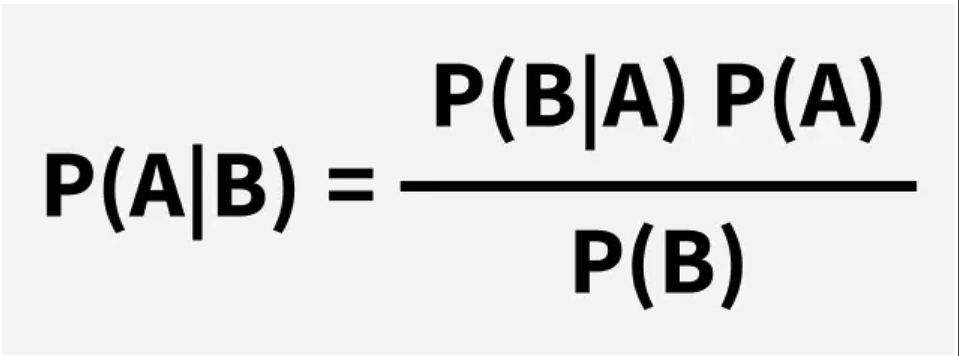




**Let’s Look into the terms:**
*  P(A) and P(B) are the probabilities of events A and B; also, P(B) is never equal to zero.
*  P(A|B) is the probability of event A when event B happens,
*  P(B|A) is the probability of event B when A happens.

**Bayes Theorem Statement**

**Bayes' Theorem for n sets of events is defined as,**

Let E1, E2,…, En be a set of events associated with the sample space S, in which all the events E1, E2,…, En have a non-zero probability of occurrence. All the events E1, E2,…, E form a partition of S. Let A be an event in space S for which we have to find the probability, then according to Bayes theorem,

$$P(E_i|A) = \frac{P(E_i) \cdot P(A|E_i)}{\sum_{k=1}^{n} P(E_k) \cdot P(A|E_k)}$$ for $k = 1, 2, 3, \dots, n$


**Bayes Theorem Derivation**

The proof of Bayes' Theorem is given as, according to the conditional probability formula,
$$P(E_i|A) = \frac{P(E_i \cap A)}{P(A)} \quad \dots(i)$$

Then, by using the multiplication rule of probability, we get

$$P(E_i \cap A) = P(E_i) \cdot P(A|E_i)\quad \dots(ii)$$

Now, by the total probability theorem,
$$P(A) = \sum_{k=1}^{n} P(E_k) \cdot P(A|E_k) \quad \dots(iii)$$

Substituting the value of P(Eᵢ∩A) and P(A) from eq (ii) and eq(iii) in eq(i) we get,

$$P(E_i|A) = \frac{P(E_i) \cdot P(A|E_i)}{\sum_{k=1}^{n} P(E_k) \cdot P(A|E_k)}$$

Bayes’ theorem is also known as the formula for the probability of “causes”. As we know, the Ei‘s are a partition of the sample space S, and at any given time, only one of the events Ei occurs. Thus, we conclude that the Bayes theorem formula gives the probability of a particular Ei, given that event A has occurred.

## **Terms Related to Bayes' Theorem**

let us understand some important terms related to the concepts we covered in the formula and derivation.

**Hypotheses**

*  [Hypotheses](https://www.geeksforgeeks.org/maths/hypothesis/) refer to possible events or outcomes in the sample space; they are denoted as E1, E2, …, En.
*  Each hypothesis represents a distinct scenario that could explain an observed event.
Priori Probability

**Priori Probability**
*  [Priori Probability](https://www.geeksforgeeks.org/maths/prior-probability/) P(Ei) is the initial probability of an event occurring before any new data is taken into account.
*  It reflects existing knowledge or assumptions about the event.
*  Example: The probability of a person having a disease before taking a test.
Posterior Probability

**Posterior probability**
*  [Posterior probability](https://www.geeksforgeeks.org/maths/posterior-probability/) (P(Ei∣A) is the updated probability of an event after considering new information.
*  It is derived using the Bayes Theorem.
*  Example: The probability of having a disease given a positive test result.

**Conditional Probability**

*  The probability of an event A based on the occurrence of another event B is termed [conditional Probability](https://www.geeksforgeeks.org/maths/conditional-probability/).
*  It is denoted as **P(A|B)** and represents the probability of A when event B has already happened.

**Joint Probability**

*  When the probability of two or more events occurring together and at the same time is measured, it is marked as [Joint Probability](https://www.geeksforgeeks.org/engineering-mathematics/joint-probability-concept-formula-and-examples/).
*  For two events A and B, it is denoted by joint probability is denoted as P(A∩B).

**Random Variables**

*  Real-valued variables whose possible values are determined by random experiments are called [random variables](https://www.geeksforgeeks.org/engineering-mathematics/random-variable/).
*  The probability of finding such variables is the experimental probability.

## **Advantage, DisAdvantage of Navie- Bayes Classifier**

### Advantage:
*  It is easy and fast to predict the class of the test data set. It also performs well in multi-class prediction.

*  When assumption of independence holds, a Naive Bayes classifier performs better compare to other models like logistic regression and you need less training data.

*  It perform well in case of categorical input variables compared to numerical variable(s). For numerical variable, normal distribution is assumed (bell curve, which is a strong assumption).

### Disadvantage:
*  Naive Bayes is also known as a bad estimator, so the probability outputs are not to be taken too seriously.

*  Another limitation of Naive Bayes is the assumption of independent predictors. In real life, it is almost impossible that we get a set of predictors which are completely independent.

# **Restaurant-reviews Sentiment Analysis**

In [1]:
import kagglehub
import numpy as np
import pandas as pd
import math
from collections import defaultdict
from tqdm import tqdm   # Progress bar

# Sklearn utilities
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report,roc_auc_score

# NLTK preprocessing
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('punkt_tab')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

## **Dataset**

In [2]:
path = kagglehub.dataset_download("hj5992/restaurantreviews")


# train_path = path+"/training.1600000.processed.noemoticon.csv"

Using Colab cache for faster access to the 'restaurantreviews' dataset.


In [3]:
df = pd.read_csv(path+"/Restaurant_Reviews.tsv", delimiter = '\t', quoting = 3)
# df = pd.read_csv(train_path,encoding="latin-1",header=None)

In [4]:
df.head(10)

,Review,Liked
0,Wow... Loved this place.,1
1,Crust is not good.,0
2,Not tasty and the texture was just nasty.,0
3,Stopped by during the late May bank holiday of...,1
4,The selection on the menu was great and so wer...,1
5,Now I am getting angry and I want my damn pho.,0
6,Honeslty it didn't taste THAT fresh.),0
7,The potatoes were like rubber and you could te...,0
8,The fries were great too.,1
9,A great touch.,1


In [5]:
df.shape

(1000, 2)

## **Preprocessing**

In [6]:
stop=stopwords.words('english')

In [7]:
def preprocess_text(text):
    """
    Preprocess text using NLTK:
    - Lowercase
    - Tokenization
    - Stopword removal
    - Lemmatization

    Args:
        text (str)

    Returns:
        str: cleaned text (joined back for vectorizer)
    """

    #first converting the text to lower case and then performing
    #word tokenize
    tokens=word_tokenize(text.lower())

    #Filtering only alphabets then use list comprehension
    word_tokens=[t for t in tokens if t.isalpha()] #only retrieve alphabets , means remove number and
    #special chars

    #Next step : to remove stopwords
    #Stop words removal
    clean_tokens=[t for t in  word_tokens if t not in stop] #remove stop words

    #next step Lemmatization
    #Create the object of WordNetLemmatizer class
    lemma=WordNetLemmatizer()
    lemma_tokens=[lemma.lemmatize(t) for t in clean_tokens]
    return ' '.join(lemma_tokens)

In [8]:
text="Go until to goes study  studing date dated  wolves the jurong point, 56 crazy.. Available only 23 ..."
print(preprocess_text(text))

go go study studing date dated wolf jurong point crazy available


## **Train-Test Split**

In [9]:
X = df['Review']
y = df['Liked']

# Split the data into training and testing sets (80% train, 20% test)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Apply preprocessing to training and testing raw text
X_train_processed = X_train_raw.apply(preprocess_text)
X_test_processed = X_test_raw.apply(preprocess_text)



In [10]:
maxlen = max(X_train_processed.apply(len))

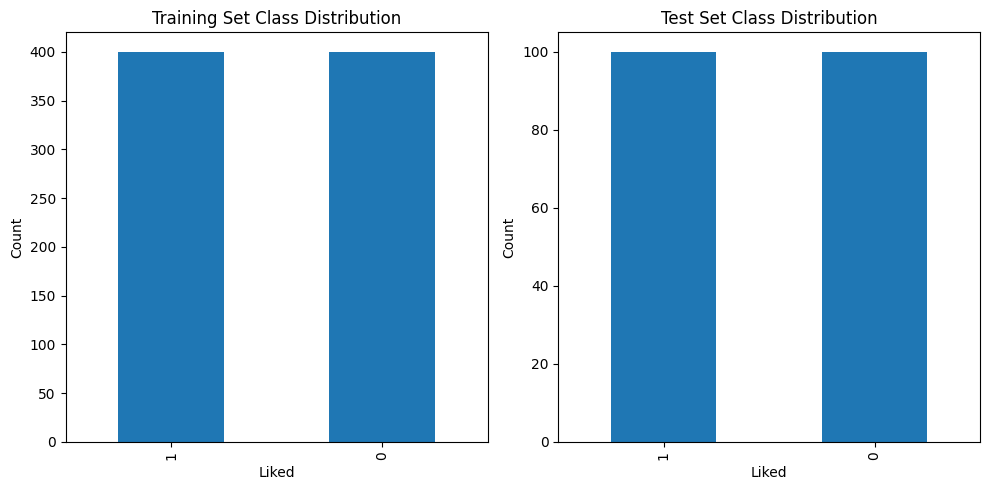

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
y_train.value_counts().plot(kind='bar', title='Training Set Class Distribution')
plt.xlabel('Liked')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
y_test.value_counts().plot(kind='bar', title='Test Set Class Distribution')
plt.xlabel('Liked')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

## **Feature Extraction**

In [12]:
# Initialize CountVectorizer
vectorizer = CountVectorizer(ngram_range=(1,3))
# vectorizer = TfidfVectorizer()
# Fit the vectorizer on the training data only to prevent data leakage
X_train = vectorizer.fit_transform(X_train_processed)

# Transform both training and testing data using the fitted vectorizer
X_test = vectorizer.transform(X_test_processed)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")


Shape of X_train: (800, 7545)
Shape of X_test: (200, 7545)
Shape of y_train: (800,)
Shape of y_test: (200,)


In [13]:
# Convert sparse matrix → dense array for our model
X_train = X_train.toarray()
X_test = X_test.toarray()

## **Naïve Bayes (From Scratch)**

In [14]:


class NaiveBayes:
    """
    Multinomial Naïve Bayes implemented from scratch
    with progress tracking using tqdm.
    """

    def __init__(self):
        self.class_probs = {}     # Prior probabilities P(class)
        self.feature_probs = {}   # Likelihood P(word | class)
        self.n_features = 0

    def fit(self, X, y):
        """
        Train Naïve Bayes model with progress bar.

        Args:
            X (numpy array): shape (n_samples, n_features)
            y (list): class labels
        """

        n_samples, self.n_features = X.shape
        classes = np.unique(y)

        # Progress bar over classes
        for c in tqdm(classes, desc="Training Classes"):

            # -----------------------------
            # PRIOR PROBABILITY
            # P(class) = count(class) / total_samples
            # -----------------------------
            X_c = X[np.array(y) == c]
            self.class_probs[c] = len(X_c) / n_samples

            # -----------------------------
            # WORD COUNT CALCULATION
            # -----------------------------
            word_counts = np.zeros(self.n_features)

            # Progress bar over samples in class
            for row in tqdm(X_c, desc=f"Processing Class {c}", leave=False):
                word_counts += row   # accumulate word counts

            # Total number of words in this class
            total_words = np.sum(word_counts)

            # -----------------------------
            # LAPLACE SMOOTHING
            # P(word|class) = (count + 1) / (total_words + vocab_size)
            # -----------------------------
            self.feature_probs[c] = (word_counts + 1) / (total_words + self.n_features)

    def predict(self, X):
        """
        Predict class labels.

        Args:
            X (numpy array)

        Returns:
            list: predictions
        """

        predictions = []

        # Progress bar for predictions
        for x in tqdm(X, desc="Predicting"):

            scores = {}

            for c in self.class_probs:
                # -----------------------------
                # LOG PRIOR
                # -----------------------------
                score = math.log(self.class_probs[c])

                # -----------------------------
                # LOG LIKELIHOOD
                # -----------------------------
                for i in range(self.n_features):
                    if x[i] > 0:
                        score += x[i] * math.log(self.feature_probs[c][i])

                scores[c] = score

            # Choose class with highest posterior
            predictions.append(max(scores, key=scores.get))

        return predictions

## **Train Model**

In [15]:
model = NaiveBayes()
model.fit(X_train, y_train)

Training Classes: 100%|██████████| 2/2 [00:00<00:00,  7.13it/s]


## **Evaluation**

In [16]:
y_pred = model.predict(X_test)
print()
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Predicting: 100%|██████████| 200/200 [00:01<00:00, 129.19it/s]



Accuracy: 0.765
Precision: 0.7264957264957265
Recall: 0.85
F1 Score: 0.783410138248848
Confusion Matrix:
 [[68 32]
 [15 85]]


In [17]:
print("classification_report:")
print(classification_report(y_test, y_pred))

classification_report:
              precision    recall  f1-score   support

           0       0.82      0.68      0.74       100
           1       0.73      0.85      0.78       100

    accuracy                           0.77       200
   macro avg       0.77      0.77      0.76       200
weighted avg       0.77      0.77      0.76       200



## **Error Analysis**

In [18]:
labels = {0:"Negative",1:"Positive"}

In [19]:
for text, true_label, pred_label in zip(X_test_processed, y_test, y_pred):
  # check which kind of text model get confuse
    if true_label != pred_label:
        print(f"Text: {text}")
        print(f"Actual: {true_label}, Predicted: {pred_label}")
        print("----")

Text: host staff lack better word bitch
Actual: 0, Predicted: 1
----
Text: service quick even go order like like
Actual: 1, Predicted: 0
----
Text: seated immediately
Actual: 1, Predicted: 0
----
Text: place clean food oh stale
Actual: 0, Predicted: 1
----
Text: found place accident could happier
Actual: 1, Predicted: 0
----
Text: miss wish one philadelphia
Actual: 1, Predicted: 0
----
Text: came back today since relocated still impressed
Actual: 0, Predicted: 1
----
Text: ca beat
Actual: 1, Predicted: 0
----
Text: thing
Actual: 0, Predicted: 1
----
Text: performed
Actual: 1, Predicted: 0
----
Text: really impressed strip steak
Actual: 0, Predicted: 1
----
Text: better dedicated boba tea spot even jenni pho
Actual: 0, Predicted: 1
----
Text: never anything complain
Actual: 1, Predicted: 0
----
Text: really like crepe station
Actual: 1, Predicted: 0
----
Text: selection food best
Actual: 0, Predicted: 1
----
Text: really impressive place closed
Actual: 0, Predicted: 1
----
Text: server 

Error analysis of the model reveals that it struggles primarily with identifying negative sentiments. The recall for the negative class is 0.64, indicating that a significant number of negative samples are misclassified as positive. In contrast, the model achieves a higher recall of 0.83 for the positive class, suggesting a bias toward predicting positive sentiment.

This issue arises due to the limitations of the Naïve Bayes algorithm and the Bag-of-Words representation, which assumes independence between words and ignores contextual relationships. As a result, the model fails to correctly interpret negations such as “not good” and misclassifies them as positive. Additionally, weak or ambiguous negative expressions are often incorrectly labeled as positive.


To address these limitations, improvements such as TF-IDF vectorization, inclusion of n-grams, and the use of more advanced classifiers like Logistic Regression or Support Vector Machines can be applied. These methods can better capture contextual information and improve the model’s ability to distinguish between positive and negative sentiments.

# **Summary of Results**

## **Model Performance Comparison**

| Feature extraction method | Accuracy | Precision | Recall | F1 Score |
|---------------------------|----------|-----------|--------|----------|
| CountVectorizer           | 0.76     | 0.76      | 0.76   | 0.75     |
| CountVectorizer(nrange(1,3)| 0.77     | 0.77      | 0.77   | 0.76     |
| TF-IDF                    | 0.73     | 0.74      | 0.73   | 0.73     |

## **Class-wise Performance**

| Feature extraction method | Class          | Precision | Recall | F1-score | Support |
|---------------------------|----------------|-----------|--------|----------|---------|
| CountVectorizer           | Negative (0)   | 0.80      | 0.68   | 0.74     | 100     |
| CountVectorizer           | Positive (1)   | 0.72      | 0.83   | 0.77     | 100     |
| CountVectorizer(nrange(1,3)| Negative (0)   | 0.82      | 0.68   | 0.74     | 100     |
| CountVectorizer(nrange(1,3)| Positive (1)   | 0.73      | 0.85   | 0.78     | 100     |
| TF-IDF                    | Negative (0)   | 0.79      | 0.64   | 0.71     | 100     |
| TF-IDF                    | Positive(1)    | 0.70      | 0.83   | 0.76     | 100     |

## **Key observations**


1. Accuracy Decreased with TF-IDF

    *    From 0.76 → 0.73

Unexpected (TF-IDF usually improves performance)


| Metric            | Count | TF-IDF |
| ----------------- | ----- | ------ |
| Recall (Negative) | 0.68  | 0.64   |

TF-IDF misses more negative samples

3. Positive Class Stayed Similar

    *  Recall remains **0.83**

    * Slight drop in precision

Model still biased toward **positive class**

4. Overall Insight

* 👉 TF-IDF **did not improve performance**
* 👉 In fact, it slightly **degraded the model**

### **Why TF-IDF Performed Worse**
**1. Small Dataset Problem**

TF-IDF works best when:

  * Large corpus is available

❌ dataset is small(1000 sample ) → IDF values become unreliable

**2. Naïve Bayes Prefers Raw Counts**

Naive Bayes works better with:

  * frequency-based features (CountVectorizer)

Why?

  * It models word occurrence probabilities

TF-IDF:

  * Distorts raw frequencies → hurts probability estimation

**3. Important Words Downweighted**

TF-IDF reduces importance of frequent words like:

  * “good”, “bad”, “love”, “hate”

 But these are critical for sentiment analysis

## **Conclusion**



A comparison was performed between CountVectorizer and TF-IDF vectorization techniques using the Naïve Bayes classifier. The model using CountVectorizer achieved an accuracy of 76%, while the TF-IDF-based model achieved a slightly lower accuracy of 73%.

It was observed that the recall for the negative class decreased from 0.68 to 0.64 when using TF-IDF, indicating that the model became less effective at identifying negative sentiment. The performance degradation can be attributed to the small dataset size and the nature of Naïve Bayes, which relies on raw frequency counts for probability estimation. TF-IDF, by reweighting word importance, may reduce the influence of key sentiment-bearing words such as “good” and “bad.”

Thus, CountVectorizer proved to be more suitable for the Naïve Bayes classifier in this case. However, TF-IDF may perform better when used with other classifiers such as Logistic Regression or Support Vector Machines.


## references

1.  bayes theorem blog https://www.geeksforgeeks.org/maths/bayes-theorem/
2.  sentiment analysis using naive bayes blog https://medium.com/@zubairashfaque/sentiment-analysis-with-naive-bayes-algorithm-a31021764fb4
3. sentiment analysis reference code https://www.kaggle.com/code/ankumagawa/sentimental-analysis-using-naive-bayes-classifier
4. restaurant review kaggle dataset
https://www.kaggle.com/datasets/hj5992/restaurantreviews
5. Fast and accurate sentiment classification using an
enhanced Naive Bayes modelby Vivek Narayanan1
, Ishan Arora2
, Arjun Bhatia. https://arxiv.org/pdf/1305.6143



